# Model Comparison & Evaluation

This Notebook automatically reads the `train_list` defined in `config.yaml`, and loads and evaluates each trained model.
You can view the following for all models at once:
- Basic Information (Training time, Path)
- Performance Metrics (Precision, Recall, F1-Score, Accuracy)
- Confusion Matrix
- Anomaly Score Distribution (Duration vs Anomaly Score)

In [1]:
import os
import sys
import sqlite3
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook is under Backend/Notebooks, so add Backend to import path
backend_dir = os.path.abspath(os.path.join('..'))
if backend_dir not in sys.path:
    sys.path.insert(0, backend_dir)

from ml_preprocessing import load_config
from ml_artifacts import load_model_artifact

plt.style.use('ggplot')

In [2]:
import copy
from sklearn.metrics import confusion_matrix

print("Loading configurations and dataset...")
# Load Config
config = load_config(os.path.join(backend_dir, 'config.yaml'))

# Resolve default model directory
project_root = os.path.abspath(os.path.join(backend_dir, '..'))
model_dir_candidates = [
    os.path.join(backend_dir, 'Models'),
    os.path.join(project_root, 'Models'),
]
resolved_model_dir = next((p for p in model_dir_candidates if os.path.exists(p)), None)

if resolved_model_dir:
    config['artifacts']['model_dir'] = resolved_model_dir

# Load Data
db_path = os.path.join(backend_dir, 'hospital_iot.db')
conn = sqlite3.connect(db_path)
df = pd.read_sql_query('SELECT * FROM Toilet_Log_Features', conn)
conn.close()

print(f"Successfully loaded {len(df)} feature records.")
print(f"Using model root directory: {resolved_model_dir}")

Loading configurations and dataset...
Successfully loaded 18590 feature records.
Using model root directory: d:\Github Clone\FYP_AIoT_system\Backend\Models


In [3]:
def evaluate_and_visualize_model(model_key, config_dict, current_df):
    print("\n" + "="*80)
    print(f"🚀 Evaluating Model: {model_key}")
    print("="*80)
    
    artifact_name = f"anomaly_model_{model_key}"
    
    # Load model artifact
    try:
        res = load_model_artifact(config=config_dict, artifact_name=artifact_name)
        if len(res) >= 3:
            preprocessor, model, meta = res[:3]
        else:
            print(f"❌ Load Failed: {artifact_name} (Invalid return length)")
            return
    except Exception as e:
         print(f"❌ Load Failed: {artifact_name} ({str(e)})")
         return
         
    if not model or not preprocessor:
         print(f"❌ Load Failed: {artifact_name} (Model is empty)")
         return

    # Print basic info
    model_dir = config_dict['artifacts']['model_dir']
    full_path = os.path.abspath(os.path.join(model_dir, artifact_name))
    threshold = meta.get('threshold')
    
    print("[ Model Basic Info ]")
    print(f"• Model Name:   {meta.get('model_name', model_key)}")
    print(f"• Created At:   {meta.get('created_at', 'Unknown')}")
    print(f"• Path:         {full_path}")
    print(f"• Threshold:    {threshold:.6f}\n" if threshold else "• Threshold:    Not Auto-Calibrated\n")
         
    y = current_df['is_accident'].values
    
    # Parse expected features
    features_in = getattr(preprocessor, 'feature_names_in_', meta.get('feature_names', []))
    features_in = list(features_in)
    if not features_in:
        # Fallback if no schema is found
        exclude_cols = ['record_id', 'user_id', 'is_accident', 'created_at', 'report_period', 'log_id', 'patient_id']
        features_in = [c for c in current_df.columns if c not in exclude_cols]
        
    print("[ Feature Information ]")
    print(f"• Total Features: {len(features_in)}")
    print(f"• Features Used: {', '.join(features_in)}\n")
        
    missing_cols = [c for c in features_in if c not in current_df.columns]
    if missing_cols:
        print(f"⚠️ Missing features in DB ({len(missing_cols)}): {missing_cols[:3]}...")
        for c in missing_cols:
            current_df[c] = 0
            
    X_raw = current_df[features_in].copy()
    
    # Transform features
    try:
        X_scaled = preprocessor.transform(X_raw)
    except Exception as e:
        print(f"❌ Feature transformation failed: {e}")
        return
    
    # Get scores
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X_scaled)
    elif callable(getattr(model, 'predict_proba', None)):
        scores = model.predict_proba(X_scaled)[:, 1]
    else:
        scores = model.predict(X_scaled)
    
    if not threshold:
        # Fallback threshold
        normal_scores = scores[y == 0]
        threshold = np.mean(normal_scores) + 3 * np.std(normal_scores)
        
    # Calculate predictions
    # Fix: use the correct logic for the new naming convention (xgboost_all, xgboost_top10, etc.)
    base_model_name = meta.get('model_name', model_key)
    if 'xgboost' in base_model_name or 'autoencoder' in base_model_name:
        y_pred = (scores > threshold).astype(int)
    else:
        # Scikit-learn isolation forest usually returns lower score for anomalies (-1)
        y_pred = (scores < threshold).astype(int)
    
    # Produce evaluation metrics
    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    print("[ Performance Metrics ]")
    print(f"Accuracy:  {accuracy:.6f}")
    print(f"Precision: {precision:.6f}")
    print(f"Recall:    {recall:.6f}")
    print(f"F1-Score:  {f1:.6f}\n")
    
    print("[ Confusion Matrix ]")
    print(f"True Negatives (Normal, no alert):       {tn:5d}  | False Positives (Normal, false alert): {fp:5d} ❌")
    print(f"False Negatives (Accident, missed alert): ❌ {fn:5d}  | True Positives  (Accident, successful alert): {tp:5d} ✅")
    print("-" * 80 + "\n")
    
    # Visualize score distribution
    fig, ax = plt.subplots(figsize=(10, 4.5))
    plot_df = pd.DataFrame({'duration_seconds': current_df['duration_seconds'], 'score': scores, 'label': y})
    
    normal_df = plot_df[plot_df['label'] == 0]
    accident_df = plot_df[plot_df['label'] == 1]
    
    ax.scatter(normal_df['duration_seconds'], normal_df['score'], s=14, alpha=0.6, color='#2ca02c', label='Normal (Label=0)')
    ax.scatter(accident_df['duration_seconds'], accident_df['score'], s=18, alpha=0.85, color='#d62728', label='Accident (Label=1)')
    ax.axhline(y=threshold, color='#1f77b4', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
    
    ax.set_title(f'{model_key} - Duration vs Anomaly Score')
    ax.set_xlabel('Duration (Seconds)')
    ax.set_ylabel('Anomaly Score')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

Preparing to evaluate the following models: ['xgboost_all', 'xgboost_filtered', 'xgboost_top10', 'isolation_forest_all', 'isolation_forest_filtered', 'isolation_forest_top10', 'simple_autoencoder_all', 'simple_autoencoder_filtered', 'simple_autoencoder_top10']

🚀 Evaluating Model: xgboost_all
??Model artifact loaded from: d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_xgboost_all
  - Created at: 2026-04-03T03:35:07.946078
  - Model type: xgboost_all
  - Features: 43
[ Model Basic Info ]
• Model Name:   xgboost_all
• Created At:   2026-04-03T03:35:07.946078
• Path:         d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_xgboost_all
• Threshold:    0.243013

[ Feature Information ]
• Total Features: 27
• Features Used: duration_seconds, time_of_day_id, hour_of_day, day_of_week, is_weekend, time_since_last_log_minutes, mean_duration_7d, max_duration_7d, min_duration_7d, std_duration_7d, log_count_7d, tod_deep_night_count_7d, tod_early_morning_count_7d, tod_late_

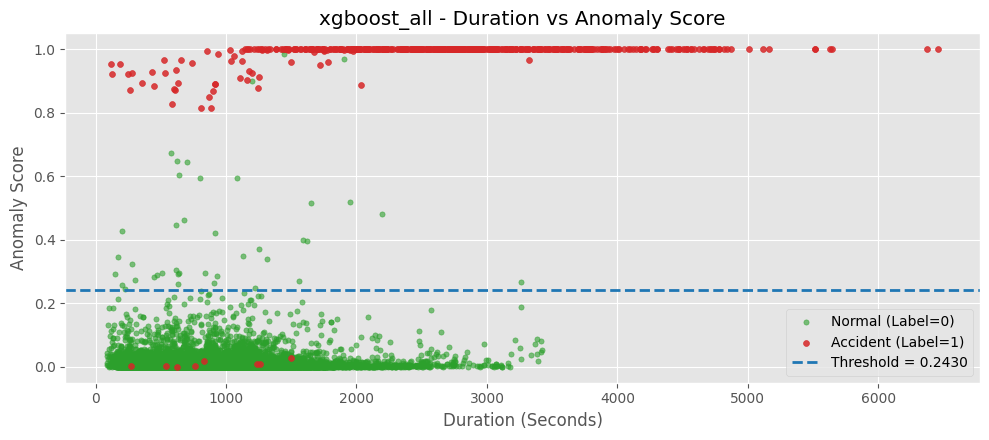


🚀 Evaluating Model: xgboost_filtered
??Model artifact loaded from: d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_xgboost_filtered
  - Created at: 2026-04-03T03:36:24.948231
  - Model type: xgboost_filtered
  - Features: 40
[ Model Basic Info ]
• Model Name:   xgboost_filtered
• Created At:   2026-04-03T03:36:24.948231
• Path:         d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_xgboost_filtered
• Threshold:    0.327711

[ Feature Information ]
• Total Features: 24
• Features Used: duration_seconds, time_of_day_id, hour_of_day, day_of_week, is_weekend, time_since_last_log_minutes, mean_duration_7d, max_duration_7d, min_duration_7d, std_duration_7d, log_count_7d, tod_deep_night_count_7d, tod_early_morning_count_7d, tod_late_morning_count_7d, tod_afternoon_count_7d, tod_evening_count_7d, accident_ratio_7d, age_x_mobility, gastro_x_duration, age, gender, mobility_level, has_gastro_issue, has_uro_issue

[ Performance Metrics ]
Accuracy:  0.996235
Precision: 0

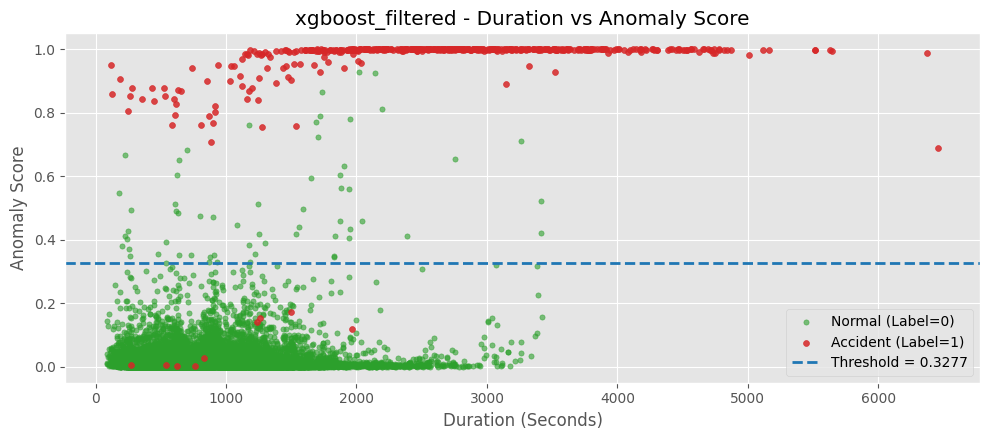


🚀 Evaluating Model: xgboost_top10
??Model artifact loaded from: d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_xgboost_top10
  - Created at: 2026-04-03T03:37:10.177527
  - Model type: xgboost_top10
  - Features: 14
[ Model Basic Info ]
• Model Name:   xgboost_top10
• Created At:   2026-04-03T03:37:10.177527
• Path:         d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_xgboost_top10
• Threshold:    0.304834

[ Feature Information ]
• Total Features: 10
• Features Used: duration_seconds, time_of_day_id, hour_of_day, mean_duration_7d, max_duration_7d, std_duration_7d, accident_ratio_7d, gastro_x_duration, report_minus_duration, duration_to_report_ratio

[ Performance Metrics ]
Accuracy:  0.996611
Precision: 0.899452
Recall:    0.984000
F1-Score:  0.939828

[ Confusion Matrix ]
True Negatives (Normal, no alert):       18035  | False Positives (Normal, false alert):    55 ❌
False Negatives (Accident, missed alert): ❌     8  | True Positives  (Accident, successf

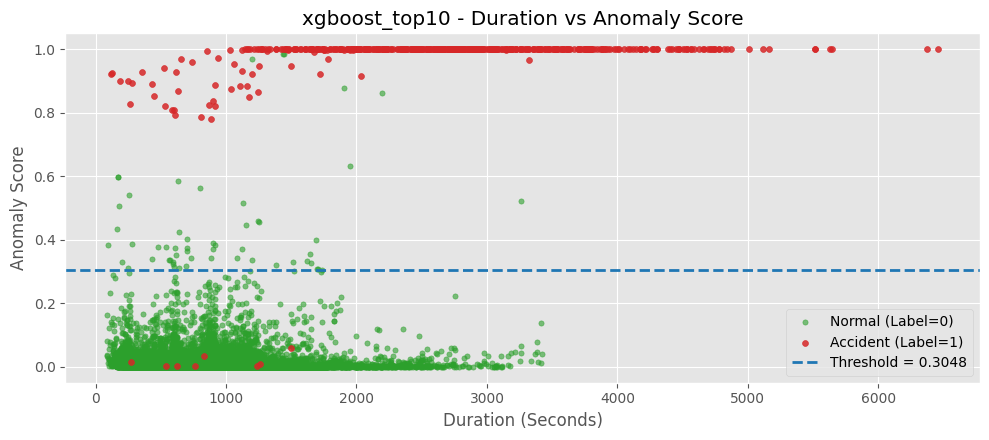


🚀 Evaluating Model: isolation_forest_all
??Model artifact loaded from: d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_isolation_forest_all
  - Created at: 2026-04-03T03:35:09.382919
  - Model type: isolation_forest_all
  - Features: 43
[ Model Basic Info ]
• Model Name:   isolation_forest_all
• Created At:   2026-04-03T03:35:09.382919
• Path:         d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_isolation_forest_all
• Threshold:    -0.001544

[ Feature Information ]
• Total Features: 27
• Features Used: duration_seconds, time_of_day_id, hour_of_day, day_of_week, is_weekend, time_since_last_log_minutes, mean_duration_7d, max_duration_7d, min_duration_7d, std_duration_7d, log_count_7d, tod_deep_night_count_7d, tod_early_morning_count_7d, tod_late_morning_count_7d, tod_afternoon_count_7d, tod_evening_count_7d, accident_ratio_7d, age_x_mobility, gastro_x_duration, age, gender, mobility_level, has_gastro_issue, has_uro_issue, self_reported_max_seconds, report_m

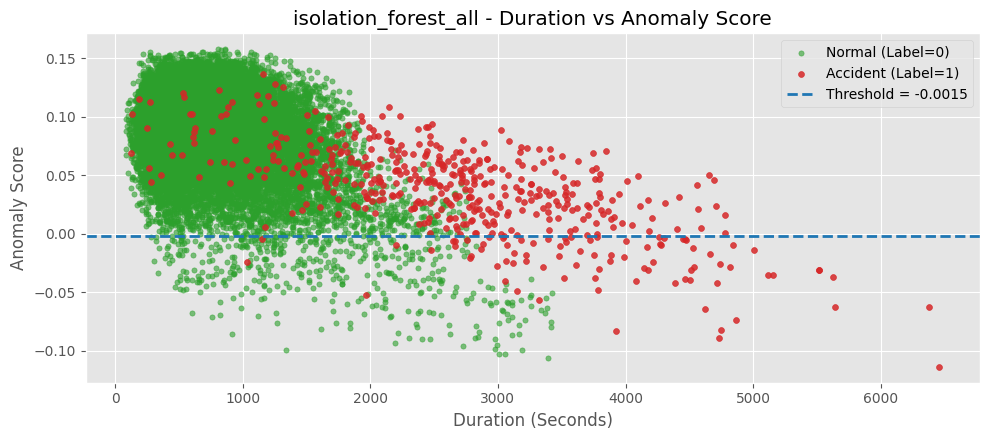


🚀 Evaluating Model: isolation_forest_filtered
??Model artifact loaded from: d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_isolation_forest_filtered
  - Created at: 2026-04-03T03:36:26.397767
  - Model type: isolation_forest_filtered
  - Features: 40
[ Model Basic Info ]
• Model Name:   isolation_forest_filtered
• Created At:   2026-04-03T03:36:26.397767
• Path:         d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_isolation_forest_filtered
• Threshold:    -0.004008

[ Feature Information ]
• Total Features: 24
• Features Used: duration_seconds, time_of_day_id, hour_of_day, day_of_week, is_weekend, time_since_last_log_minutes, mean_duration_7d, max_duration_7d, min_duration_7d, std_duration_7d, log_count_7d, tod_deep_night_count_7d, tod_early_morning_count_7d, tod_late_morning_count_7d, tod_afternoon_count_7d, tod_evening_count_7d, accident_ratio_7d, age_x_mobility, gastro_x_duration, age, gender, mobility_level, has_gastro_issue, has_uro_issue

[ Performa

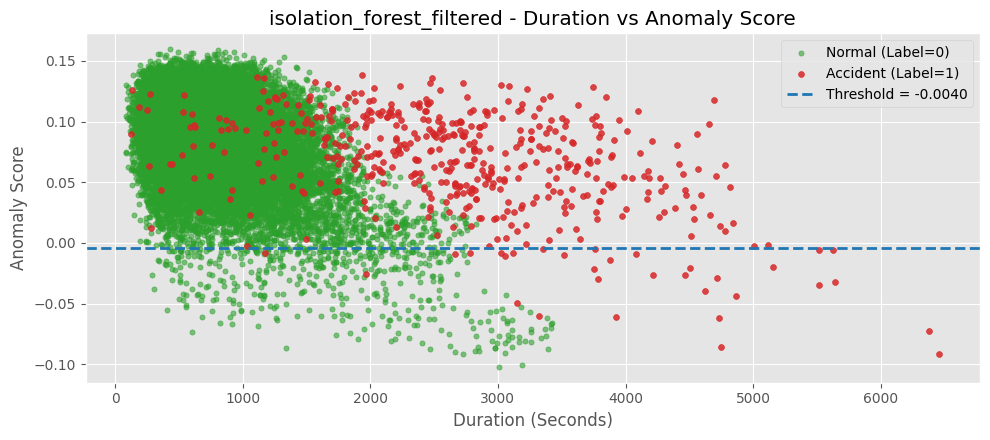


🚀 Evaluating Model: isolation_forest_top10
??Model artifact loaded from: d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_isolation_forest_top10
  - Created at: 2026-04-03T03:37:11.403248
  - Model type: isolation_forest_top10
  - Features: 14
[ Model Basic Info ]
• Model Name:   isolation_forest_top10
• Created At:   2026-04-03T03:37:11.403248
• Path:         d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_isolation_forest_top10
• Threshold:    -0.005062

[ Feature Information ]
• Total Features: 10
• Features Used: duration_seconds, time_of_day_id, hour_of_day, mean_duration_7d, max_duration_7d, std_duration_7d, accident_ratio_7d, gastro_x_duration, report_minus_duration, duration_to_report_ratio

[ Performance Metrics ]
Accuracy:  0.967402
Precision: 0.390947
Recall:    0.380000
F1-Score:  0.385396

[ Confusion Matrix ]
True Negatives (Normal, no alert):       17794  | False Positives (Normal, false alert):   296 ❌
False Negatives (Accident, missed alert): 

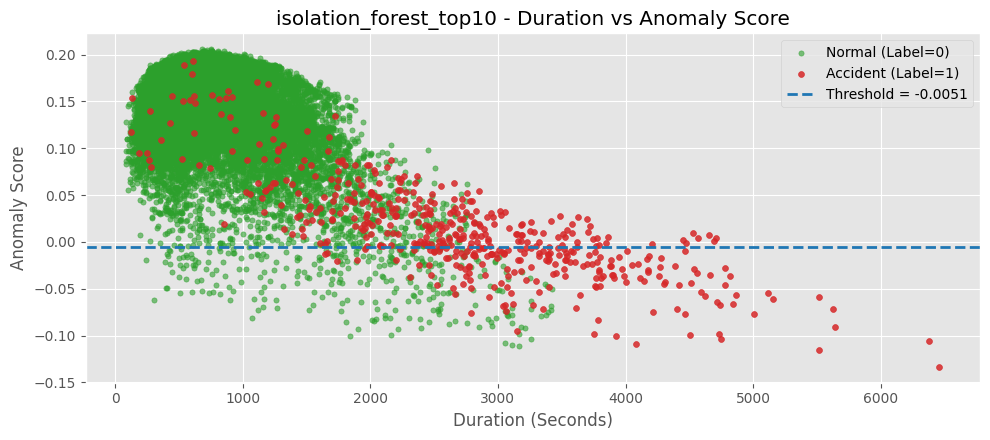


🚀 Evaluating Model: simple_autoencoder_all
??Model artifact loaded from: d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_simple_autoencoder_all
  - Created at: 2026-04-03T03:36:23.980796
  - Model type: simple_autoencoder_all
  - Features: 43
[ Model Basic Info ]
• Model Name:   simple_autoencoder_all
• Created At:   2026-04-03T03:36:23.980796
• Path:         d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_simple_autoencoder_all
• Threshold:    0.362155

[ Feature Information ]
• Total Features: 27
• Features Used: duration_seconds, time_of_day_id, hour_of_day, day_of_week, is_weekend, time_since_last_log_minutes, mean_duration_7d, max_duration_7d, min_duration_7d, std_duration_7d, log_count_7d, tod_deep_night_count_7d, tod_early_morning_count_7d, tod_late_morning_count_7d, tod_afternoon_count_7d, tod_evening_count_7d, accident_ratio_7d, age_x_mobility, gastro_x_duration, age, gender, mobility_level, has_gastro_issue, has_uro_issue, self_reported_max_seconds,

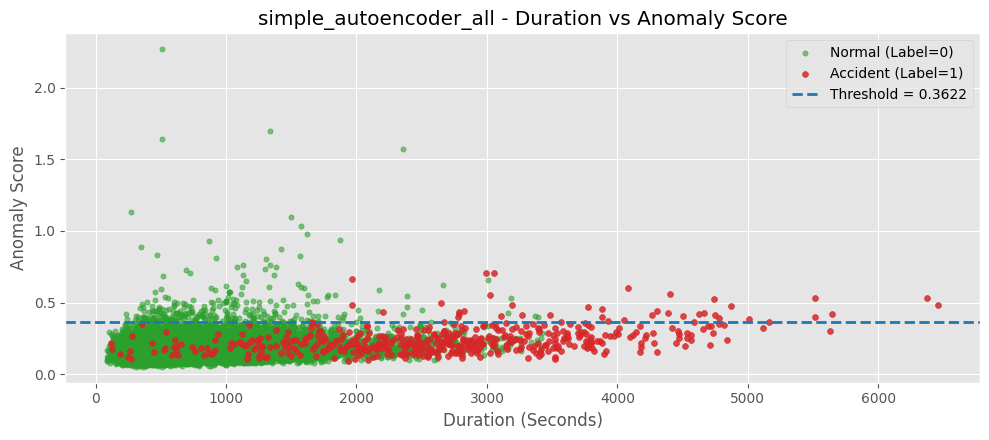


🚀 Evaluating Model: simple_autoencoder_filtered
??Model artifact loaded from: d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_simple_autoencoder_filtered
  - Created at: 2026-04-03T03:37:09.623737
  - Model type: simple_autoencoder_filtered
  - Features: 40
[ Model Basic Info ]
• Model Name:   simple_autoencoder_filtered
• Created At:   2026-04-03T03:37:09.623737
• Path:         d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_simple_autoencoder_filtered
• Threshold:    0.362106

[ Feature Information ]
• Total Features: 24
• Features Used: duration_seconds, time_of_day_id, hour_of_day, day_of_week, is_weekend, time_since_last_log_minutes, mean_duration_7d, max_duration_7d, min_duration_7d, std_duration_7d, log_count_7d, tod_deep_night_count_7d, tod_early_morning_count_7d, tod_late_morning_count_7d, tod_afternoon_count_7d, tod_evening_count_7d, accident_ratio_7d, age_x_mobility, gastro_x_duration, age, gender, mobility_level, has_gastro_issue, has_uro_issue

[

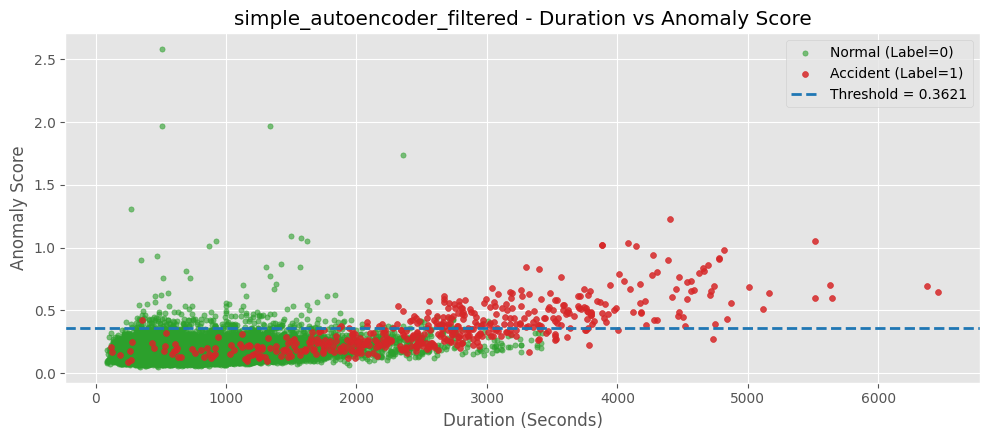


🚀 Evaluating Model: simple_autoencoder_top10
??Model artifact loaded from: d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_simple_autoencoder_top10
  - Created at: 2026-04-03T03:39:03.423635
  - Model type: simple_autoencoder_top10
  - Features: 14
[ Model Basic Info ]
• Model Name:   simple_autoencoder_top10
• Created At:   2026-04-03T03:39:03.423635
• Path:         d:\Github Clone\FYP_AIoT_system\Backend\Models\anomaly_model_simple_autoencoder_top10
• Threshold:    0.200994

[ Feature Information ]
• Total Features: 10
• Features Used: duration_seconds, time_of_day_id, hour_of_day, mean_duration_7d, max_duration_7d, std_duration_7d, accident_ratio_7d, gastro_x_duration, report_minus_duration, duration_to_report_ratio

[ Performance Metrics ]
Accuracy:  0.964874
Precision: 0.337580
Recall:    0.318000
F1-Score:  0.327497

[ Confusion Matrix ]
True Negatives (Normal, no alert):       17778  | False Positives (Normal, false alert):   312 ❌
False Negatives (Accident, missed

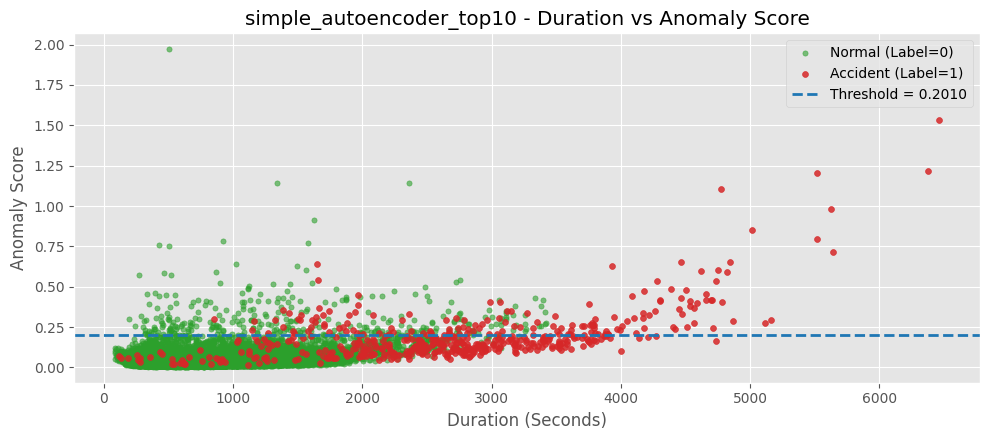

In [4]:
# Check trained models list for evaluation
base_models = config['models'].get('train_list', [])
strategies = ['all', 'filtered', 'top10']

# Fallback to primary if the list is empty
if not base_models:
    base_models = [config['models']['primary']]

# Build the complete list of models to evaluate
models_to_evaluate = []
for model_base in base_models:
    # We will let it try to evaluate simple_autoencoder now
    for strategy in strategies:
        models_to_evaluate.append(f"{model_base}_{strategy}")

print(f"Preparing to evaluate the following models: {models_to_evaluate}")

for m in models_to_evaluate:
    evaluate_and_visualize_model(m, config, df)